# Stage 2: Model comparison and manual CV

This notebook trains multiple models (scikit-learn + external libraries), runs **manual** stratified cross-validation, and compares test metrics with tables, plots, and confusion matrices.

Requires: `xgboost`, `lightgbm`, `catboost`.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from second_stage.metrics import compute_metrics, plot_confusion


In [2]:
splits_dir = PROJECT_ROOT / "second_stage" / "splits"
train_path = splits_dir / "train.csv"
val_path = splits_dir / "val.csv"
test_path = splits_dir / "test.csv"

for p in [train_path, val_path, test_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing split file: {p}")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

target_col = "loan_status"
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

X_train_val = train_val_df.drop(columns=[target_col])
y_train_val = train_val_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print("Train+Val:", X_train_val.shape, "Test:", X_test.shape)


Train+Val: (36000, 22) Test: (9000, 22)


In [3]:
def to_labels(preds, threshold=0.5):
    preds = np.asarray(preds)
    if preds.ndim == 2:
        if preds.shape[1] == 2:
            return (preds[:, 1] >= threshold).astype(int)
        return preds.argmax(axis=1)
    if preds.dtype.kind in "fc":
        if np.all((preds >= 0) & (preds <= 1)):
            return (preds >= threshold).astype(int)
    return preds.astype(int)


def manual_stratified_cv(model_factory, X, y, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        model = model_factory()
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = to_labels(model.predict(X.iloc[val_idx]))
        metrics = compute_metrics(y.iloc[val_idx], preds, positive_label=1)
        metrics["fold"] = fold
        fold_rows.append(metrics)
    return pd.DataFrame(fold_rows)


In [4]:
models = {
    "LogisticRegression": lambda: LogisticRegression(max_iter=1000, solver="lbfgs"),
    "RandomForest": lambda: RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoosting": lambda: GradientBoostingClassifier(random_state=42),
    "SVC": lambda: SVC(kernel="rbf", C=1.0, gamma="scale"),
    "XGBoost": lambda: XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),
    "LightGBM": lambda: LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
    ),
    "CatBoost": lambda: CatBoostClassifier(
        iterations=400,
        learning_rate=0.1,
        depth=6,
        loss_function="Logloss",
        verbose=False,
        random_state=42,
    ),
}


In [5]:
metrics_order = ["accuracy", "precision", "recall", "f1", "specificity"]

cv_rows = []
for name, factory in models.items():
    fold_metrics = manual_stratified_cv(factory, X_train_val, y_train_val, n_splits=5, random_state=42)
    mean = fold_metrics[metrics_order].mean()
    std = fold_metrics[metrics_order].std()
    row = {"model": name}
    for metric in metrics_order:
        row[f"{metric}_mean"] = mean[metric]
        row[f"{metric}_std"] = std[metric]
    cv_rows.append(row)

cv_summary = pd.DataFrame(cv_rows).set_index("model")
cv_formatted = pd.DataFrame(index=cv_summary.index)
for metric in metrics_order:
    cv_formatted[metric] = cv_summary.apply(
        lambda r: f"{r[f'{metric}_mean']:.4f} ± {r[f'{metric}_std']:.4f}",
        axis=1,
    )

display(cv_formatted)


[LightGBM] [Info] Number of positive: 6400, number of negative: 22400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000325 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2055
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222222 -> initscore=-1.252763
[LightGBM] [Info] Start training from score -1.252763
[LightGBM] [Info] Number of positive: 6400, number of negative: 22400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2057
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222222 -> initscore=-1.252763
[Lig

,accuracy,precision,recall,f1,specificity
model,,,,,
LogisticRegression,0.8874 ± 0.0014,0.7637 ± 0.0066,0.7146 ± 0.0127,0.7383 ± 0.0051,0.9368 ± 0.0032
RandomForest,0.9159 ± 0.0015,0.8813 ± 0.0072,0.7184 ± 0.0086,0.7915 ± 0.0044,0.9723 ± 0.0021
GradientBoosting,0.9129 ± 0.0016,0.8629 ± 0.0055,0.7232 ± 0.0103,0.7869 ± 0.0051,0.9671 ± 0.0019
SVC,0.9049 ± 0.0017,0.8369 ± 0.0069,0.7109 ± 0.0086,0.7687 ± 0.0047,0.9604 ± 0.0022
XGBoost,0.9201 ± 0.0022,0.8710 ± 0.0083,0.7519 ± 0.0114,0.8070 ± 0.0060,0.9681 ± 0.0026
LightGBM,0.9193 ± 0.0021,0.8731 ± 0.0079,0.7452 ± 0.0114,0.8041 ± 0.0061,0.9690 ± 0.0024
CatBoost,0.9194 ± 0.0014,0.8750 ± 0.0079,0.7438 ± 0.0073,0.8040 ± 0.0034,0.9696 ± 0.0024


In [6]:
test_rows = []
trained_models = {}
for name, factory in models.items():
    model = factory()
    model.fit(X_train_val, y_train_val)
    preds = to_labels(model.predict(X_test))
    metrics = compute_metrics(y_test, preds, positive_label=1)
    metrics["model"] = name
    test_rows.append(metrics)
    trained_models[name] = model

test_results = pd.DataFrame(test_rows).set_index("model")
display(test_results.round(4))


[LightGBM] [Info] Number of positive: 8000, number of negative: 28000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2059
[LightGBM] [Info] Number of data points in the train set: 36000, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222222 -> initscore=-1.252763
[LightGBM] [Info] Start training from score -1.252763


,accuracy,precision,recall,f1,specificity
model,,,,,
LogisticRegression,0.8921,0.7783,0.7195,0.7477,0.9414
RandomForest,0.9166,0.8796,0.7235,0.7940,0.9717
GradientBoosting,0.9123,0.8619,0.7210,0.7852,0.9670
SVC,0.9073,0.8390,0.7215,0.7758,0.9604
XGBoost,0.9230,0.8749,0.7625,0.8149,0.9689
LightGBM,0.9210,0.8780,0.7485,0.8081,0.9703
CatBoost,0.9226,0.8768,0.7580,0.8131,0.9696


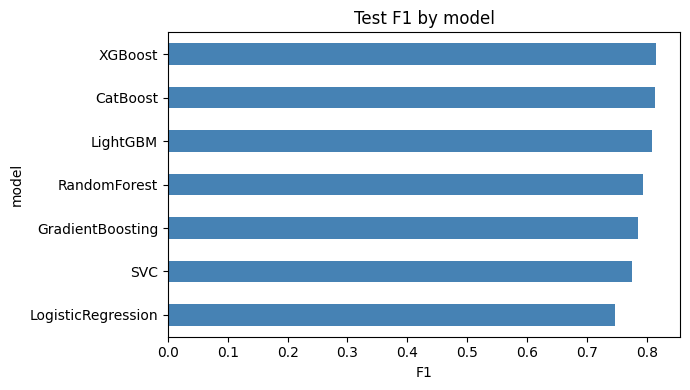

In [7]:
ax = test_results["f1"].sort_values().plot.barh(figsize=(7, 4), color="steelblue")
ax.set_title("Test F1 by model")
ax.set_xlabel("F1")
plt.tight_layout()


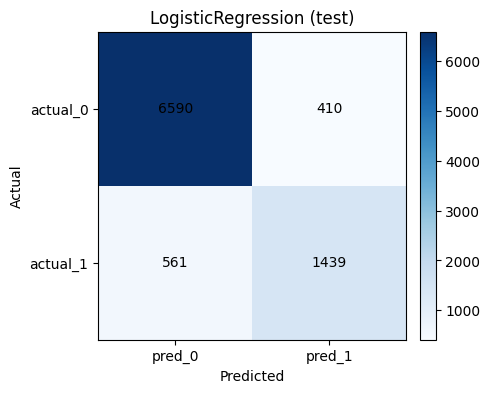

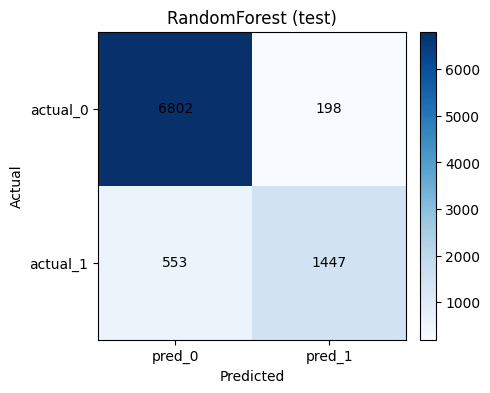

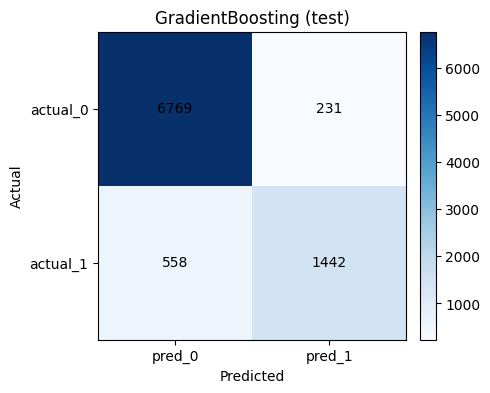

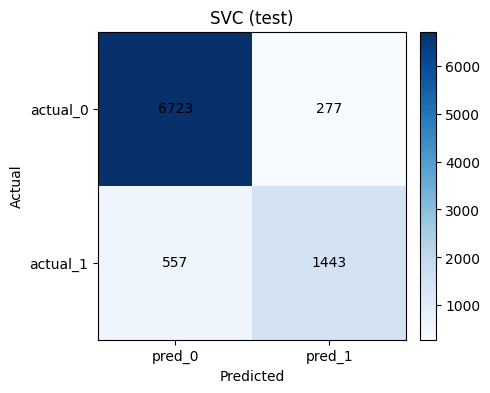

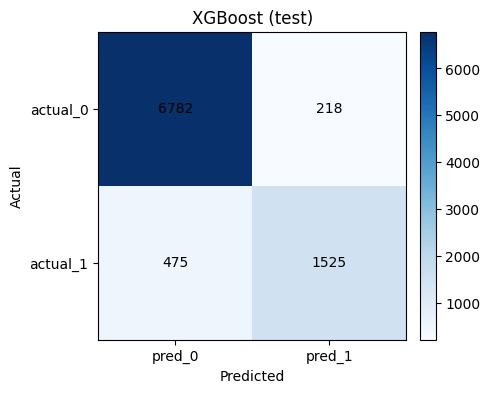

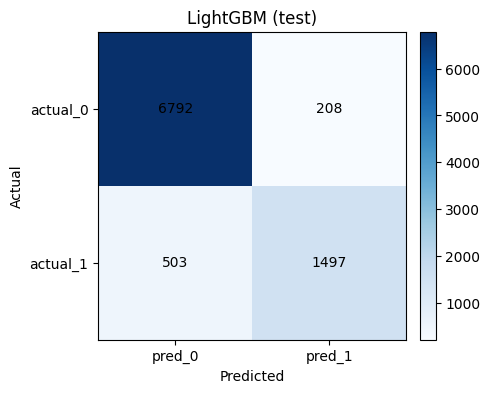

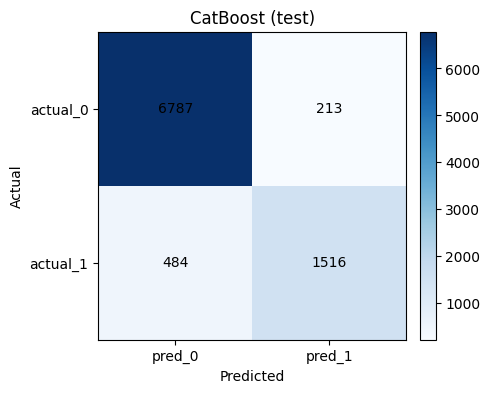

In [8]:
for name, model in trained_models.items():
    preds = to_labels(model.predict(X_test))
    plot_confusion(y_test, preds, title=f"{name} (test)")
    plt.show()
